# Sahel cereal yields & climate shocks — main analysis

**How much do drought years reduce millet and sorghum yields across the Sahel,
once the long-run yield trend is removed?**

Millet and sorghum are the primary *subsistence* cereals across the Sahel —
they feed tens of millions of people directly, as food security rather than as
a tradable commodity. The relationship between rainfall variability and yield
is the load-bearing climate-adaptation question for the region, yet the debate
is often dominated by narrative or by single-country case studies. This project
produces a clean, defensible point estimate of the **average drought-year yield
deviation** across six countries — Burkina Faso, Mali, Niger, Senegal, Chad and
Mauritania — with explicit robustness checks.

**Scope.** This is a *descriptive* estimate of an average effect in a small
panel (6 countries × ~64 years). It is **not** a yield forecast, **not** an
attribution of the droughts themselves to climate change, and **not** a source
of country-specific policy recommendations.

**How to read this notebook.** Every load-bearing data-processing choice is
presented as a **five-part decision block** — problem, diagnostic, options,
decision + rationale, sensitivity (see `notebooks/NOTEBOOK_STRUCTURE.md`). No
choice is conventional; each is anchored in a diagnostic on the actual data.
This notebook covers panel assembly and the data/climate decisions
(6, 1, 3); `02_main.ipynb` continues with the estimation decisions and the
event study.

## Part 0 — setup

The analysis reads only built artifacts: the pinned FAOSTAT snapshot and the
raw CRU / GADM / cropland inputs through the `sahel_yields` package. Nothing is
fetched live (see Decision 6).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sahel_yields import data, climate, econ, diagnostics

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 4)

## Part 1 — FAOSTAT yields

Yields are national annual millet and sorghum yields (kg/ha) for the six Sahel
countries, 1961-2024, from FAOSTAT (domain *Production: Crops and livestock
products*).

In [2]:
fao = data.load_faostat_snapshot()
print(f"snapshot date : {data.SNAPSHOT_DATE}")
print(f"rows          : {len(fao)}  ({fao.iso3.nunique()} countries"
      f" x {fao.crop.nunique()} crops x {fao.year.nunique()} years)")
print(f"years         : {fao.year.min()}-{fao.year.max()}")
fao.head()

snapshot date : 2026-05-19
rows          : 768  (6 countries x 2 crops x 64 years)
years         : 1961-2024


,iso3,country,crop,year,yield_kg_ha,flag
0,BFA,Burkina Faso,millet,1961,316.8,A
1,BFA,Burkina Faso,millet,1962,438.0,A
2,BFA,Burkina Faso,millet,1963,383.5,A
3,BFA,Burkina Faso,millet,1964,468.7,A
4,BFA,Burkina Faso,millet,1965,393.8,E


### Decision 6 — FAOSTAT snapshot pinning

**Problem.** FAOSTAT revises historical yield figures as countries submit
corrections. The *same query* run six months apart can return different
numbers, which would silently change the headline event-study coefficient with
no code change — the analysis would not be reproducible.

**Diagnostic.** Below: the FAOSTAT data-quality flag composition. Flag `A` is
an official figure, `E` an FAO estimate, `X` a figure sourced from another
international organisation. Non-official (`E`/`X`) values are the ones most
exposed to future revision.

**Options.**
- Option A — *pin a dated snapshot*: ingest once, write a date-stamped parquet,
  read only that parquet downstream. Fully reproducible.
- Option B — *read FAOSTAT live every run*: always current, never reproducible.
- Option C — *pin but auto-refresh on a schedule*: reproducible within a
  refresh window, silent breaks across windows.

**Decision.** **Option A.** This notebook reads
`faostat_snapshot_2026-05-19.parquet` exclusively; re-fetching is the explicit,
documented `data.write_faostat_snapshot()` step, never implicit. For a
*descriptive* study the reproducibility of the headline number outweighs data
currency (Principle 2 — reliability over a marginal freshness gain).

**Sensitivity.** The rigorous sensitivity check is a *revision-magnitude*
diagnostic — the median absolute yield change between two snapshots taken
months apart. Only one snapshot exists so far, so that delta is not yet
observable; when a second snapshot is taken, that comparison is run and the
analysis is either re-pinned or kept, with the magnitude documented. As a proxy
for revision *exposure* now, the cell below quantifies the share of
country-years carrying a non-official flag — these bound where a future
revision could land.

In [3]:
flag_meaning = {"A": "official", "E": "FAO estimate", "X": "intl-org figure"}
flags = fao["flag"].value_counts().rename_axis("flag").reset_index(name="n")
flags["meaning"] = flags["flag"].map(flag_meaning)
flags["pct_of_panel"] = (flags["n"] / len(fao) * 100).round(1)
print(flags.to_string(index=False))
print()
diagnostics.missingness_summary(fao)

flag   n         meaning  pct_of_panel
   A 670        official          87.2
   E  53    FAO estimate           6.9
   X  45 intl-org figure           5.9



,n_missing,pct_missing
iso3,0,0.0
country,0,0.0
crop,0,0.0
year,0,0.0
yield_kg_ha,0,0.0
flag,0,0.0


In [4]:
# Sensitivity proxy: how much of the panel is revision-exposed, and where.
non_official = fao[fao["flag"].isin(["E", "X"])]
share = len(non_official) / len(fao) * 100
print(f"revision-exposed (non-official) country-years: "
      f"{len(non_official)} of {len(fao)}  ({share:.1f}%)")
print("\nnon-official rows by country x crop:")
print(non_official.groupby(["iso3", "crop"]).size().unstack(fill_value=0))
print("\nre-fetch is an explicit step:  data.write_faostat_snapshot('<new-date>')")

revision-exposed (non-official) country-years: 98 of 768  (12.8%)

non-official rows by country x crop:
crop  millet  sorghum
iso3                 
BFA        5        8
MRT       37       37
NER        2        4
SEN        1        1
TCD        2        1

re-fetch is an explicit step:  data.write_faostat_snapshot('<new-date>')


## Part 2 — the climate layer (SPI)

Drought is identified from the **Standardized Precipitation Index (SPI)** built
from CRU TS precipitation. The pipeline: weight 0.5° CRU gridcells up to a
country aggregate, sum precipitation over each country's growing season, fit a
gamma distribution per country and map season totals to SPI (McKee et al.
1993). SPI is computed here under **both** spatial-weighting modes — area and
cropland — so Decision 3 can compare them on the actual series.

> The cell below opens the ~6 GB CRU netCDF and runs the gridcell→country
> intersection (~30-60 s). It is the slow step; everything downstream is cheap.

In [5]:
pre = data.load_cru_pre()                       # CRU precip, subset to Sahel bbox
gadm = data.load_gadm(level=0)                  # admin-0 boundaries
with data.load_cropland() as cropland_src:      # year-2000 cropland fraction
    weights = climate.gridcells_to_country(pre, gadm, cropland_src)
print(f"CRU cell-country weight rows: {len(weights)}")

spi = {}
for mode in ("area", "cropland"):
    season = climate.growing_season_precip(pre, weights, mode=mode)
    spi[mode] = climate.compute_spi(season)
print(f"SPI computed for both modes; series span "
      f"{spi['area'].year.min()}-{spi['area'].year.max()}.")

CRU cell-country weight rows: 2102
SPI computed for both modes; series span 1901-2024.


**SPI sanity check.** By construction SPI should be ~N(0, 1) per country. The
gamma fit uses the full 1901-2024 CRU climatology, so mean ≈ 0 and sd ≈ 1
within rounding confirms the fit is well-behaved before any drought flagging.

In [6]:
for mode, df in spi.items():
    g = df.groupby("iso3")["spi"].agg(["mean", "std"])
    print(f"[{mode:>8}]  per-country SPI mean in "
          f"[{g['mean'].min():+.3f}, {g['mean'].max():+.3f}]  "
          f"sd in [{g['std'].min():.3f}, {g['std'].max():.3f}]")

[    area]  per-country SPI mean in [+0.000, +0.001]  sd in [1.004, 1.004]
[cropland]  per-country SPI mean in [+0.000, +0.000]  sd in [1.004, 1.004]


### Decision 1 — drought definition

**Problem.** The whole analysis hinges on which country-years count as
"drought". The SPI threshold sets a trade-off: a *lax* cutoff floods the event
study with marginal events — false positives that attenuate the estimate toward
zero — while a *strict* cutoff keeps only severe droughts but leaves too few
events to identify event-time coefficients across just six countries.

**Diagnostic.** Below: the drought count at each candidate threshold, both as a
share of the panel and as the minimum number of events any single country
contributes (the binding constraint for the country-clustered event study).

**Options.**
- Option A — `SPI < -0.8` ("abnormally dry"): lax; maximises events.
- Option B — `SPI < -1.0` (McKee et al. 1993 "moderately dry"): the standard
  cutoff.
- Option C — `SPI < -1.5` ("severely dry"): strict; few but unambiguous events.

**Decision.** **Option B, `SPI < -1.0`.** The diagnostic shows -0.8 pushes the
drought share toward a third of all country-years — too lax to read as a
*shock* against a non-drought baseline — while -1.5 leaves some countries with
only a handful of events, too thin for stable event-time coefficients. -1.0 is
both the literature-standard "moderately dry" cutoff *and* the value that keeps
every country adequately populated. The threshold is re-run as a robustness
axis in `03_robustness.ipynb`.

The other two facets of the drought definition are settled upstream and are not
free parameters here. The **growing-season window** is fixed per country in
`climate.GROWING_SEASON` from the FAO crop calendar (e.g. Niger millet Jun-Sep;
Mauritania's shorter Jul-Sep). And SPI is built on the **season-total**
(multi-month cumulative) precipitation, not a single-month minimum: rainfed
millet and sorghum draw on rainfall across the whole season, so the cumulative
total is the agronomically correct exposure — a single dry month inside an
otherwise normal season is not a drought.

**Sensitivity.** The threshold feeds a full robustness sweep (-0.8 / -1.0 /
-1.5) in `03_robustness.ipynb`; the cell below also lists the drought years per
country at -1.0 so the flagged events can be eyeballed against the known
Sahel drought record (the early-1970s and mid-1980s pan-Sahel droughts should
appear).

In [7]:
panel_years = range(int(fao.year.min()), int(fao.year.max()) + 1)
spi_area = spi["area"][spi["area"].year.isin(panel_years)]

alts = {}
for thr in (-0.8, -1.0, -1.5):
    flag = spi_area["spi"] < thr
    per_country = spi_area.assign(flag=flag).groupby("iso3")["flag"].sum()
    alts[f"SPI < {thr}"] = {
        "n_drought": int(flag.sum()),
        "pct_of_panel": round(flag.mean() * 100, 1),
        "min_events_in_a_country": int(per_country.min()),
        "max_events_in_a_country": int(per_country.max()),
    }
diagnostics.compare_alternatives(alts)

,n_drought,pct_of_panel,min_events_in_a_country,max_events_in_a_country
SPI < -0.8,116,30.2,14,26
SPI < -1.0,92,24.0,12,20
SPI < -1.5,43,11.2,6,8


In [8]:
# Sensitivity: the flagged drought years at SPI < -1.0, per country.
flagged = climate.flag_drought(spi_area, threshold=-1.0)
years_by_country = (flagged[flagged.drought]
                    .groupby("iso3")["year"]
                    .apply(lambda y: ", ".join(map(str, sorted(y)))))
print(f"SPI < -1.0  ->  {int(flagged.drought.sum())} drought country-years\n")
for iso3, yrs in years_by_country.items():
    print(f"  {iso3}: {yrs}")

SPI < -1.0  ->  92 drought country-years

  BFA: 1972, 1973, 1976, 1978, 1982, 1983, 1984, 1987, 1990, 1997, 2000, 2002, 2004
  MLI: 1972, 1973, 1976, 1977, 1979, 1982, 1983, 1984, 1985, 1986, 1987, 1990, 1992, 1993, 1996, 1997, 2000, 2002
  MRT: 1972, 1973, 1977, 1979, 1980, 1982, 1983, 1984, 1987, 1990, 1991, 1992, 1996, 2002
  NER: 1971, 1972, 1973, 1982, 1983, 1984, 1985, 1987, 1990, 1996, 1997, 2002
  SEN: 1968, 1970, 1972, 1973, 1977, 1979, 1980, 1982, 1983, 1984, 1990, 1991, 1992, 1993, 1996, 1997, 2001, 2002, 2004, 2014
  TCD: 1972, 1973, 1976, 1982, 1983, 1984, 1985, 1986, 1987, 1990, 1993, 1996, 2000, 2001, 2002


### Decision 3 — spatial weighting from CRU grid to country aggregate

**Problem.** CRU precipitation is a 0.5° (~55 km) grid and country boundaries
cut across cells. Rolling cells up to a country series needs a weighting rule,
and the choice is **not** cosmetic — it changes the SPI series and therefore
which years are flagged as drought. Treating desert cells the same as cropland
cells is a real distortion in the Sahel: most of Mauritania and northern Mali
is desert, and rainfall there says nothing about millet yields.

**Diagnostic.** Below: the area-weighted and cropland-weighted SPI series
compared — their correlation, mean absolute gap, the count of drought flags
that change between them, and per-country panels so the disagreement can be
located geographically.

**Options.**
- Option A — *area-weighted*: each cell weighted by overlap area with the
  country. Simplest; gives desert and cropland equal voice.
- Option B — *cropland-area-weighted*: overlap area scaled by the EarthStat
  year-2000 cropland fraction of the cell — rainfall *where the crops grow*.
- Option C — *population-weighted*: standard in temperature-exposure work, but
  population is irrelevant to where a rainfed cereal is grown; not considered.

**Decision.** **Option B, cropland-weighted.** The two SPI series correlate
highly overall, but they still disagree on a non-trivial number of drought
flags — and, critically, the disagreement *concentrates in the desert-heavy
countries* (see the per-country gap in the sensitivity cell), which is exactly
where area-weighting is least defensible: it lets empty Saharan cells outvote
the cultivated south. Since the question is about *yields*, the weighting must
follow the cropland. The added dependency is one static raster (EarthStat
Cropland2000), already loaded — a cheap price for removing a known bias.
The analytic panel is therefore built on the **cropland-weighted** SPI.

**Sensitivity.** The area-weighted SPI is carried through as the alternate
specification in `03_robustness.ipynb`; the per-country gap below shows the
choice barely moves the well-watered countries (Burkina Faso, Senegal) and
moves the desert-margin countries most — the expected and intended pattern.

In [9]:
cmp = (spi["area"][spi["area"].year.isin(panel_years)]
       .merge(spi["cropland"][spi["cropland"].year.isin(panel_years)],
              on=["iso3", "year"], suffixes=("_area", "_crop")))
cmp["drought_area"] = cmp["spi_area"] < -1.0
cmp["drought_crop"] = cmp["spi_crop"] < -1.0
cmp["flag_changed"] = cmp["drought_area"] != cmp["drought_crop"]

corr = np.corrcoef(cmp["spi_area"], cmp["spi_crop"])[0, 1]
print(f"SPI correlation, area vs cropland : {corr:.3f}")
print(f"mean |SPI_area - SPI_crop|        : {(cmp.spi_area - cmp.spi_crop).abs().mean():.3f}")
print(f"drought flags that change         : {int(cmp.flag_changed.sum())} of {len(cmp)}")

SPI correlation, area vs cropland : 0.978
mean |SPI_area - SPI_crop|        : 0.161
drought flags that change         : 20 of 384


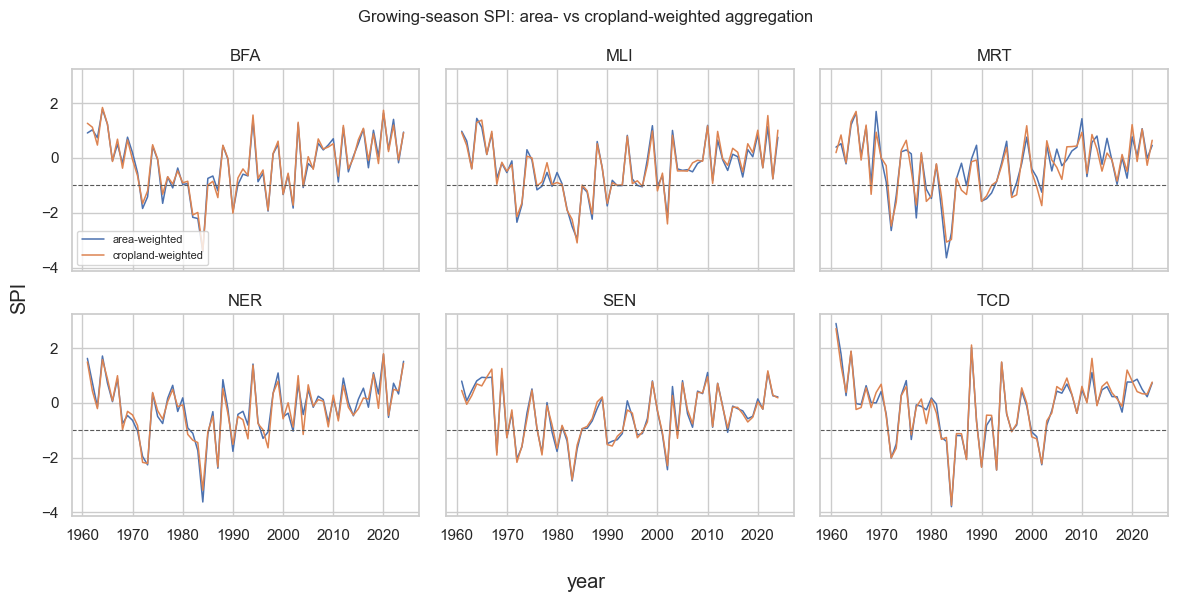

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, (iso3, g) in zip(axes.flat, cmp.groupby("iso3")):
    ax.plot(g.year, g.spi_area, lw=1.1, label="area-weighted")
    ax.plot(g.year, g.spi_crop, lw=1.1, label="cropland-weighted")
    ax.axhline(-1.0, color="0.35", ls="--", lw=0.8)
    ax.set_title(iso3)
axes[0, 0].legend(fontsize=8, loc="lower left")
fig.suptitle("Growing-season SPI: area- vs cropland-weighted aggregation",
             fontsize=12)
fig.supxlabel("year"); fig.supylabel("SPI")
fig.tight_layout()
plt.show()

In [11]:
# Sensitivity: where does the weighting choice actually bite?
cmp["abs_diff"] = (cmp["spi_area"] - cmp["spi_crop"]).abs()
gap = cmp.groupby("iso3")["abs_diff"].mean().sort_values(ascending=False)
changed = cmp.groupby("iso3")["flag_changed"].sum()
sens = pd.DataFrame({"mean_abs_SPI_gap": gap.round(3),
                     "drought_flags_changed": changed}).loc[gap.index]
print("Per-country impact of the area -> cropland weighting switch:")
print(sens)

Per-country impact of the area -> cropland weighting switch:
      mean_abs_SPI_gap  drought_flags_changed
iso3                                         
MRT              0.272                      5
NER              0.196                      6
TCD              0.139                      0
MLI              0.132                      6
BFA              0.122                      1
SEN              0.106                      2


## Part 3 — assembling the analytic panel

Decisions 1 and 3 fix the climate inputs: **cropland-weighted** SPI, drought
flagged at **`SPI < -1.0`**. The analytic panel is the inner join of the pinned
FAOSTAT snapshot with this flagged SPI series on `(iso3, year)`. The SPI series
runs 1901-2024 but FAOSTAT yields run 1961-2024, so the join keeps the
1961-2024 overlap (the longer SPI climatology already served its purpose in the
gamma fit). `log_yield` is added for the event study. The panel is written to
`data/processed/analytic_panel.parquet` as the canonical estimation input.

In [12]:
climate_canonical = climate.flag_drought(spi["cropland"], threshold=-1.0)
panel = econ.build_panel(fao, climate_canonical, write=True)
print(f"analytic panel : {panel.shape[0]} rows x {panel.shape[1]} cols"
      f"  ->  {econ.PANEL_PATH.name}")
panel.head()

analytic panel : 768 rows x 10 cols  ->  analytic_panel.parquet


,iso3,country,crop,year,yield_kg_ha,flag,season_precip,spi,drought,log_yield
0,BFA,Burkina Faso,millet,1961,316.8,A,740.2653,1.2651,False,5.7583
1,BFA,Burkina Faso,millet,1962,438.0,A,728.2378,1.1210,False,6.0822
2,BFA,Burkina Faso,millet,1963,383.5,A,675.4685,0.4694,False,5.9493
3,BFA,Burkina Faso,millet,1964,468.7,A,789.6561,1.8413,False,6.1500
4,BFA,Burkina Faso,millet,1965,393.8,E,737.5319,1.2325,False,5.9758


In [13]:
print("coverage by crop:")
print(panel.groupby("crop").agg(
    n=("year", "size"),
    year_min=("year", "min"),
    year_max=("year", "max"),
    n_drought=("drought", "sum"),
    mean_yield=("yield_kg_ha", "mean")))
print()
print("drought country-year-crop rows:",
      f"{int(panel.drought.sum())} of {len(panel)}")
print()
diagnostics.missingness_summary(panel)

coverage by crop:
           n  year_min  year_max  n_drought  mean_yield
crop                                                   
millet   384      1961      2024         86    547.7083
sorghum  384      1961      2024         86    673.6328

drought country-year-crop rows: 172 of 768



,n_missing,pct_missing
iso3,0,0.0
country,0,0.0
crop,0,0.0
year,0,0.0
yield_kg_ha,0,0.0
flag,0,0.0
season_precip,0,0.0
spi,0,0.0
drought,0,0.0
log_yield,0,0.0


---

The panel is assembled and inspected; the three data/climate decisions (6, 1,
3) are documented in full five-part form. **Session 5B** continues `02_main` —
Decision 2 (trend specification), Decision 4 (partial drought years), Decision 5
(robust standard errors), the event study on log millet and sorghum yields, the
DiD cross-check, and the hero figure.